<a href="https://colab.research.google.com/github/KingTechnician/shared-truth/blob/main/tiu_probe_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Clone Truth is Universal fork

In [ ]:
!git clone https://github.com/KingTechnician/Truth_is_Universal.git

Install `skops` (needed for easy upload of trained model)

In [ ]:
!pip install skops

## Import Libraries

In [3]:
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from collections import defaultdict
from tqdm import tqdm
import os
import sys
import glob
from huggingface_hub import login, HfApi
import json
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from skops import card
import skops.io as sio
from sklearn.metrics import roc_auc_score

HF token authentication (for uploading the model)

In [4]:
USE_COLAB = False

if USE_COLAB:

    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

else:
    from dotenv import load_dotenv
    load_dotenv()

# Optional: Verify the token is active
login(token=os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
tiu_path = "/home/kingtechnician/st-research/Truth_is_Universal"

%cd $tiu_path

# Add the repository path to sys.path to enable library imports
repo_path = '/content/Truth_is_Universal'
if repo_path not in sys.path:
    sys.path.append(repo_path)

# Import TiU probes
try:
    from probes import TTPD, LRProbe

    print("✅ Successfully imported Truth_is_Universal libraries.")

except ImportError as e:
    print(f"Error importing libraries: {e}")

/home/kingtechnician/st-research/Truth_is_Universal
✅ Successfully imported Truth_is_Universal libraries.


## Configuration

In [6]:

HF_DATASET_NAME = "KingTechnician/tiu-acts-gemma-7b-instruct-layer-19" # Replace with desired HF dataset name
LAYER_ACTS_COL = "layer_19_acts"

In [7]:
print(f"Loading {HF_DATASET_NAME}...")
dataset = load_dataset(HF_DATASET_NAME)
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

# The 12 standard training sets used in the TiU paper
train_topics_base = ["cities", "sp_en_trans", "inventors", "animal_class", "element_symb", "facts"]

def prepare_training_tensors(df, held_out_topics=None):
    """Filters df for training topics, balances them, and returns required tensors."""
    if held_out_topics is None:
        held_out_topics = []

    allowed_topics = [t for t in train_topics_base if t not in held_out_topics]

    # Filter to only the simple statements of allowed topics
    sub_df = df[(df['topic'].isin(allowed_topics)) & (df['statement_type'] == 'simple')].copy()

    # We must balance the data: equal numbers of True/False and Affirmed/Negated per topic
    min_count = sub_df.groupby(['topic', 'polarity', 'label']).size().min()

    # Sample to balance
    balanced_df = sub_df.groupby(['topic', 'polarity', 'label']).sample(n=min_count, random_state=42)

    acts_list = []
    acts_centered_list = []
    labels_list = []
    polarities_list = []

    # Calculate topic means for centering
    for topic in allowed_topics:
        topic_df = balanced_df[balanced_df['topic'] == topic]
        topic_acts = np.stack(topic_df[LAYER_ACTS_COL].values)
        topic_mean = np.mean(topic_acts, axis=0)

        acts_list.append(torch.tensor(topic_acts, dtype=torch.float32))
        acts_centered_list.append(torch.tensor(topic_acts - topic_mean, dtype=torch.float32))

        # The TiU code expects labels and polarities as float tensors
        labels_list.append(torch.tensor(topic_df['label'].values == 1, dtype=torch.float32))
        polarities_list.append(torch.tensor((topic_df['polarity'].values == 'affirmed') * 2 - 1, dtype=torch.float32))

    return (
        torch.cat(acts_centered_list),
        torch.cat(acts_list),
        torch.cat(labels_list),
        torch.cat(polarities_list)
    )


Loading KingTechnician/tiu-acts-gemma-7b-instruct-layer-19...


Generating test split: 100%|██████████| 2684/2684 [00:00<00:00, 19776.04 examples/s]


## Cross-validation

Cross-validation:   0%|          | 0/30 [00:00<?, ?it/s]/home/kingtechnician/st-research/shared-truth-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/kingtechnician/st-research/shared-truth-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
Cross-validation:   3%|▎         | 1/30 [00:00<00:16,  1.76it/s]/home/kingtech

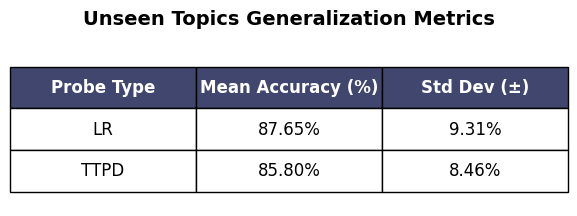

Table saved as 'probe_metrics_table.png'


In [8]:

probe_types = [TTPD, LRProbe]
results = {TTPD: defaultdict(list), LRProbe: defaultdict(list)}
num_iter = 5

topic_pairs = [(train_topics_base[i], train_topics_base[i+1]) for i in range(0, len(train_topics_base), 2)]

with tqdm(total=len(probe_types) * num_iter * len(topic_pairs), desc="Cross-validation") as pbar:
    for probe_type in probe_types:
        for n in range(num_iter):
            for pair in topic_pairs:
                # Prepare data excluding the pair
                acts_centered, acts, labels, polarities = prepare_training_tensors(train_df, held_out_topics=pair)

                # Train Probe
                if probe_type == TTPD:
                    probe = TTPD.from_data(acts_centered, acts, labels, polarities)
                elif probe_type == LRProbe:
                    probe = LRProbe.from_data(acts, labels)

                # Evaluate on the held-out test data
                for topic in pair:
                    test_sub = test_df[(test_df['topic'] == topic) & (test_df['statement_type'] == 'simple')]
                    test_acts = torch.tensor(np.stack(test_sub[LAYER_ACTS_COL].values), dtype=torch.float32)
                    test_labels = torch.tensor(test_sub['label'].values == 1, dtype=torch.int)

                    preds = probe.pred(test_acts)
                    acc = (preds == test_labels).float().mean().item()
                    results[probe_type][topic].append(acc)

                pbar.update(1)

# Create a plot-friendly dataframe
plot_data = []
for probe_type, topic_dict in results.items():
    name = "TTPD" if probe_type == TTPD else "LR"
    for topic, acc_list in topic_dict.items():
        for acc in acc_list:
            plot_data.append({
                "Probe": name,
                "Topic": topic,
                "Accuracy": acc * 100
            })

df_results = pd.DataFrame(plot_data)

# Save the raw data for future tracking
df_results.to_csv("probe_performance_log.csv", index=False)

#
# Calculate the summary statistics
summary = df_results.groupby("Probe")["Accuracy"].agg(['mean', 'std']).reset_index()
summary.columns = ["Probe Type", "Mean Accuracy (%)", "Std Dev (±)"]

# Round for a cleaner look
summary["Mean Accuracy (%)"] = summary["Mean Accuracy (%)"].map("{:.2f}%".format)
summary["Std Dev (±)"] = summary["Std Dev (±)"].map("{:.2f}%".format)

# Create matplotlib table
fig, ax = plt.subplots(figsize=(6, 2)) # Adjust size to fit your table
ax.axis('off')
ax.axis('tight')

# Create the table object
table = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center',
    colColours=["#40466e"] * len(summary.columns) # Dark header
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.5) # Scale width and height of cells

# Format header text color to white
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.get_text().set_color('white')
        cell.get_text().set_weight('bold')

# Save and show
plt.title("Unseen Topics Generalization Metrics", fontsize=14, pad=20, fontweight='bold')
plt.savefig("probe_metrics_table.png", dpi=300, bbox_inches='tight')
plt.show()

print("Table saved as 'probe_metrics_table.png'")

## Test Set Performance

In [9]:
# Train on ALL base training topics
acts_centered, acts, labels, polarities = prepare_training_tensors(train_df, held_out_topics=[])

ttpd_probe = TTPD.from_data(acts_centered, acts, labels, polarities)
lr_probe = LRProbe.from_data(acts, labels)

# Define our test groups based on dataset columns
groups = {
    'Conjunctions': test_df[test_df['statement_type'] == 'conjunction'],
    'Disjunctions': test_df[test_df['statement_type'] == 'disjunction'],
    'Affirmative German': test_df[(test_df['language'] == 'de') & (test_df['polarity'] == 'affirmed')],
    'Negated German': test_df[(test_df['language'] == 'de') & (test_df['polarity'] == 'negated')],
}




/home/kingtechnician/st-research/shared-truth-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/kingtechnician/st-research/shared-truth-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/kingtechnician/st-research/shared-truth-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 

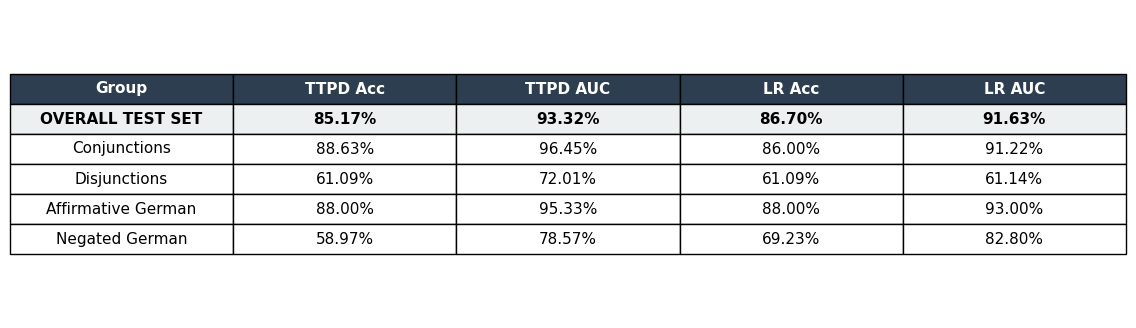

Full results table saved to probing_results_summary.png


In [10]:


# Calculate overall test set performance
all_test_acts = torch.tensor(np.stack(test_df[LAYER_ACTS_COL].values), dtype=torch.float32)
all_test_labels_np = test_df['label'].values == 1
all_test_labels = torch.tensor(all_test_labels_np, dtype=torch.int)

# Projections
ttpd_all_probs = ttpd_probe.predict_proba(all_test_acts)
lr_all_probs = lr_probe.predict_proba(all_test_acts)

ttpd_all_acc = (ttpd_probe.pred(all_test_acts) == all_test_labels).float().mean().item() * 100
lr_all_acc = (lr_probe.pred(all_test_acts) == all_test_labels).float().mean().item() * 100
ttpd_all_auc = roc_auc_score(all_test_labels_np, ttpd_all_probs) * 100
lr_all_auc = roc_auc_score(all_test_labels_np, lr_all_probs) * 100

# Initialize table data with the "Total" row
table_data = [[
    "OVERALL TEST SET",
    f"{ttpd_all_acc:.2f}%",
    f"{ttpd_all_auc:.2f}%",
    f"{lr_all_acc:.2f}%",
    f"{lr_all_auc:.2f}%"
]]

# Calculate individual group performance
for group_name, group_df in groups.items():
    if len(group_df) == 0: continue

    g_acts = torch.tensor(np.stack(group_df[LAYER_ACTS_COL].values), dtype=torch.float32)
    g_labels_np = group_df['label'].values == 1
    g_labels = torch.tensor(g_labels_np, dtype=torch.int)

    # Metrics
    g_ttpd_acc = (ttpd_probe.pred(g_acts) == g_labels).float().mean().item() * 100
    g_lr_acc = (lr_probe.pred(g_acts) == g_labels).float().mean().item() * 100

    if len(np.unique(g_labels_np)) > 1:
        g_ttpd_auc = f"{roc_auc_score(g_labels_np, ttpd_probe.predict_proba(g_acts)) * 100:.2f}%"
        g_lr_auc = f"{roc_auc_score(g_labels_np, lr_probe.predict_proba(g_acts)) * 100:.2f}%"
    else:
        g_ttpd_auc, g_lr_auc = "N/A", "N/A"

    table_data.append([group_name, f"{g_ttpd_acc:.2f}%", g_ttpd_auc, f"{g_lr_acc:.2f}%", g_lr_auc])

# Render Matplotlib table
headers = ["Group", "TTPD Acc", "TTPD AUC", "LR Acc", "LR AUC"]
fig, ax = plt.subplots(figsize=(12, len(table_data) * 0.6 + 1))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=table_data, colLabels=headers, cellLoc='center', loc='center')

# Styling
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for (row, col), cell in table.get_celld().items():
    # Header Styling
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    # Highlight the "Overall" Row (row 1 in the table object)
    elif row == 1:
        cell.set_facecolor('#ecf0f1') # Light Gray background
        cell.set_text_props(weight='bold')

plt.savefig("probing_results_summary.png", bbox_inches='tight', dpi=300)
plt.show()

print("Full results table saved to probing_results_summary.png")

## Model and Results Upload

In [ ]:
# Establish model name
repo_prefix = f"{HF_DATASET_NAME.split("/")[-1]}-probe"
repo_prefix

# Save model locally
model_path = "model.skops"

sio.dump(ttpd_probe.LR, model_path)

# Initialize HF API for uploading
api = HfApi()

# Set repo ID

repo_id = f"KingTechnician/{repo_prefix}"

# Create the initial repo and upload model file

api.create_repo(repo_id=repo_id,repo_type="model",exist_ok=True)


api.upload_file(
    path_or_fileobj=model_path,
    path_in_repo=model_path,
    repo_id=repo_id,
    repo_type="model"
)

In [ ]:
# Creating README documentation
llm_name = HF_DATASET_NAME.split("-layer")[0].split("tiu-acts-")[1]

layer_index = HF_DATASET_NAME.split("-")[-1]


metrics_markdown = """

## Unseen Topics Generalization Metrics

![Unseen Topics](probe_metrics_table.png)

## Overall and Topic-Specific Test Performance

![Test Performance](probing_results_summary.png)
"""


md_template = f"""---
tags:
- sklearn
- tabular-classification
---

# TTPD Probe

TTPD Probe for {HF_DATASET_NAME}

This is a linear probe trained on the activations of {llm_name} at layer {layer_index}.

{metrics_markdown}
"""

with open("README.md","w") as f:
  f.write(md_template)


# Upload README documents

api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=repo_id,
    repo_type="model"
)

for file_path in ["probe_metrics_table.png","probing_results_summary.png"]:


  api.upload_file(
      path_or_fileobj=file_path,
      path_in_repo=file_path,
      repo_id=repo_id,
      repo_type="model"
)

In [ ]:
# Extract and upload truth directions

t_G = ttpd_probe.t_g
t_P = ttpd_probe.polarity_direc

probe_json = {
    "t_G":t_G.tolist(),
    "t_P":t_P.tolist()
}

with open("truth_directions.json","w") as f:
  f.write(json.dumps(probe_json,indent=3))

api.upload_file(
    path_or_fileobj="truth_directions.json",
    path_in_repo="truth_directions.json",
    repo_id=repo_id,
    repo_type="model"
)